In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/softec-26-ml-competition/test/test/main_df_test.csv
/kaggle/input/competitions/softec-26-ml-competition/test/test/drg_df_test.csv
/kaggle/input/competitions/softec-26-ml-competition/test/test/cpt_df_test.csv
/kaggle/input/competitions/softec-26-ml-competition/test/test/icd_df_test.csv
/kaggle/input/competitions/softec-26-ml-competition/test/test/dob_df.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/main_df_train.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/cpt_df_train.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/drg_df_train.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/icd_df_train.csv
/kaggle/input/competitions/softec-26-ml-competition/train/train/dob_df.csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, precision_score, recall_score, roc_auc_score
from sklearn.preprocessing import LabelEncoder

import lightgbm as lgb

import warnings
warnings.filterwarnings("ignore")

In [3]:
# TRAIN
main_train = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/main_df_train.csv")
cpt_train  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/cpt_df_train.csv")
icd_train  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/icd_df_train.csv")
drg_train  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/drg_df_train.csv")
dob_train  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/train/train/dob_df.csv")

# TEST
main_test = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/main_df_test.csv")
cpt_test  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/cpt_df_test.csv")
icd_test  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/icd_df_test.csv")
drg_test  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/drg_df_test.csv")
dob_test  = pd.read_csv("/kaggle/input/competitions/softec-26-ml-competition/test/test/dob_df.csv")

print("All data loaded ✅")

All data loaded ✅


In [4]:
main_train = main_train[main_train["MONTH"].isin([-1, 12])]
main_test  = main_test[main_test["MONTH"].isin([-1, 12])]

In [5]:
main_train["HighCostLabel"] = (main_train["NEXT_YEAR_COST"] > 30000).astype(int)

In [6]:
def main_features(df):
    
    # 🔹 Cost ratios (correct columns)
    df["cost_ratio_inpatient"]  = df["Inpatient_Cost"] / (df["TotalCost"] + 1)
    df["cost_ratio_outpatient"] = df["OutpatientVisits_Cost"] / (df["TotalCost"] + 1)
    
    # 🔹 HCC trend (VERY IMPORTANT FEATURE 🔥)
    df["hcc_change_1yr"] = df["MemberHccScore"] - df["MemberHccScoreLastYear"]
    df["hcc_change_2yr"] = df["MemberHccScore"] - df["MemberHccScoreLastTwoYear"]
    
    # 🔹 Utilization intensity
    df["visit_per_claim"] = df["ProviderVisitCount"] / (df["TotalClaims"] + 1)
    
    # 🔹 Emergency severity
    df["emergency_ratio"] = df["EmergencyDepartmentVisits"] / (df["ProviderVisitCount"] + 1)
    
    # 🔹 Chronic burden (VERY HIGH IMPACT 🔥)
    df["chronic_ratio"] = df["ChronicConditions"] / (df["TotalClaims"] + 1)
    
    # 🔹 Cost intensity
    df["cost_per_claim"] = df["TotalCost"] / (df["TotalClaims"] + 1)
    
    # 🔹 Admission severity
    df["admission_ratio"] = df["Inpatient"] / (df["ProviderVisitCount"] + 1)
    
    return df

main_train = main_features(main_train)
main_test  = main_features(main_test)

In [7]:
def agg_features(df, possible_cols):
    
    col = None
    for c in possible_cols:
        if c in df.columns:
            col = c
            break
    
    if col is None:
        return pd.DataFrame(columns=["Member_Key","YEAR"])
    
    agg = df.groupby(["Member_Key","YEAR"])[col].agg(["count","nunique"])
    agg.columns = [f"{col}_count", f"{col}_nunique"]
    
    return agg.reset_index()


cpt_tr = agg_features(cpt_train, ["CPT_Code","CPT"])
cpt_te = agg_features(cpt_test, ["CPT_Code","CPT"])

icd_tr = agg_features(icd_train, ["ICD_Code","ICD"])
icd_te = agg_features(icd_test, ["ICD_Code","ICD"])

drg_tr = agg_features(drg_train, ["DRG_Code","DRG"])
drg_te = agg_features(drg_test, ["DRG_Code","DRG"])

In [8]:
def merge_all(main, cpt, icd, drg, dob):
    df = main.copy()
    
    for d in [cpt, icd, drg]:
        if len(d.columns) > 2:
            df = df.merge(d, on=["Member_Key","YEAR"], how="left")
    
    df = df.merge(dob, on="Member_Key", how="left")
    
    return df

train = merge_all(main_train, cpt_tr, icd_tr, drg_tr, dob_train)
test  = merge_all(main_test,  cpt_te, icd_te, drg_te, dob_test)

In [9]:
# REMOVE LEAKAGE 
leak_cols = [
    "NEXT_YEAR_COST",
    "Leakage_Cost",
    "PredictedCost"
]

train = train.drop(columns=leak_cols, errors="ignore")
test  = test.drop(columns=leak_cols, errors="ignore")

# Drop ID columns except Member_Key
drop_cols = ["Member_Key"]
X_cols = [c for c in train.columns if c not in drop_cols + ["HighCostLabel"]]

# Fill missing
num_cols = train[X_cols].select_dtypes(include=np.number).columns

train[num_cols] = train[num_cols].fillna(train[num_cols].median())
test[num_cols]  = test[num_cols].fillna(test[num_cols].median())

In [10]:
cat_cols = train.select_dtypes(include="object").columns

for col in cat_cols:
    full = pd.concat([train[col], test[col]]).astype(str)
    
    le = LabelEncoder()
    le.fit(full)
    
    train[col] = le.transform(train[col].astype(str))
    test[col]  = le.transform(test[col].astype(str))

In [11]:
train_data = train[train["YEAR"] < 2024]

X = train_data.drop(["HighCostLabel","Member_Key"], axis=1)
y = train_data["HighCostLabel"]

X_test = test.drop(["Member_Key"], axis=1)

In [12]:
# Data split strategy
print("📈 DATA SPLIT STRATEGY")
print(f"Training data: YEAR < 2024 ({len(train_data)} rows)")
print(f"Test data: All years available ({len(X_test)} rows)")
print("\nNote: Model trained on historical data, evaluated on full test set")
print(f"Training target distribution:\n{(y.value_counts() / len(y) * 100).round(2)}")

📈 DATA SPLIT STRATEGY
Training data: YEAR < 2024 (109562 rows)
Test data: All years available (12387 rows)

Note: Model trained on historical data, evaluated on full test set
Training target distribution:
HighCostLabel
0    88.82
1    11.18
Name: count, dtype: float64


In [13]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof = np.zeros(len(X))
test_preds = np.zeros(len(X_test))

scale_pos_weight = (y==0).sum() / (y==1).sum()

for fold, (tr_idx, val_idx) in enumerate(folds.split(X, y)):
    print(f"\nFold {fold}")
    
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]
    
    model = lgb.LGBMClassifier(
        n_estimators=800,
        learning_rate=0.03,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=4 
    )
    
    # verbose removed
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_val, y_val)],
        eval_metric="auc"
    )
    
    oof[val_idx] = model.predict_proba(X_val)[:,1]
    test_preds += model.predict_proba(X_test)[:,1] / 5


Fold 0
[LightGBM] [Info] Number of positive: 9798, number of negative: 77851
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.182829 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27598
[LightGBM] [Info] Number of data points in the train set: 87649, number of used features: 255
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111787 -> initscore=-2.072618
[LightGBM] [Info] Start training from score -2.072618

Fold 1
[LightGBM] [Info] Number of positive: 9798, number of negative: 77851
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.177451 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 27590
[LightGBM] [Info] Number of data points in the train set: 87649, number of used features: 255
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.111787 -> initscore=-2.072618
[LightGBM] [Info] Start training from score -2.0

In [14]:
print(oof.min(), oof.max())

0.00296422859220565 0.9983709324862217


In [15]:
# Calculate AUC-ROC Score
auc_score = roc_auc_score(y, oof)
print(f"OOF AUC-ROC Score: {auc_score:.4f}")
print(f"OOF Prediction range: [{oof.min():.4f}, {oof.max():.4f}]")

OOF AUC-ROC Score: 0.7889
OOF Prediction range: [0.0030, 0.9984]



 TOP 15 MOST IMPORTANT FEATURES:
                          feature  importance
5                  MemberHccScore        2643
305                       DOB_Key        2437
261                   AWVLastDate        1734
174               LastPCPProvider        1691
303                cost_per_claim        1452
296          cost_ratio_inpatient        1121
302                 chronic_ratio        1095
297         cost_ratio_outpatient        1058
72                      Diagnosis         888
74                    TotalClaims         814
282                     OtherCost         755
96   LaboratoryAndOtherTests_Cost         749
94                Procedures_Cost         746
278                    OfficeCost         734
95                   Imaging_Cost         721


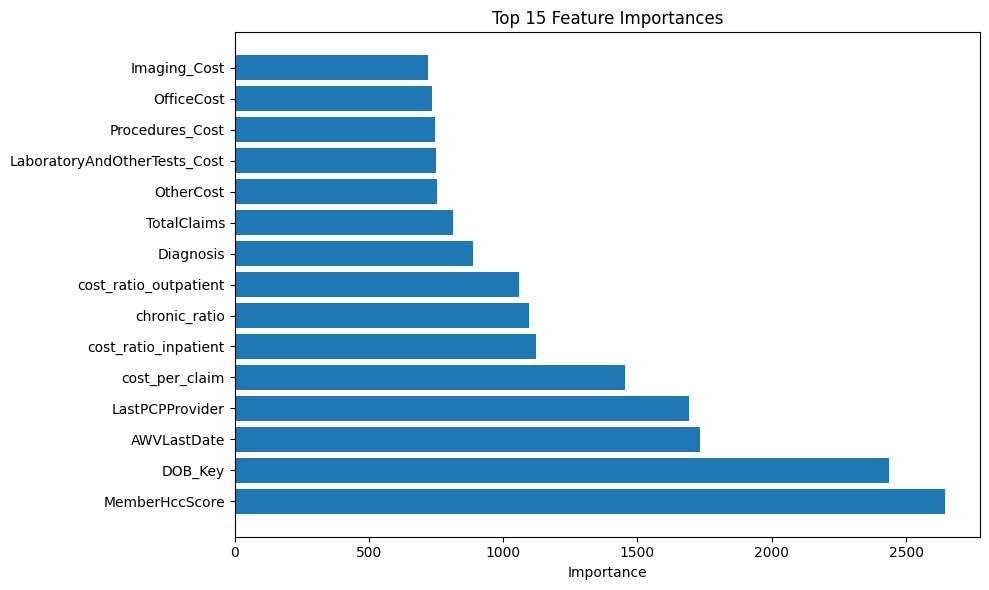

In [16]:
# Feature importance from last fold
import matplotlib.pyplot as plt

feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=False)

print("\n TOP 15 MOST IMPORTANT FEATURES:")
print(feature_importance.head(15))

plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(15)['feature'], feature_importance.head(15)['importance'])
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.tight_layout()
plt.show()

In [17]:
from sklearn.metrics import f1_score, precision_score, recall_score

best_f1 = 0
best_thresh = 0

for t in np.arange(0.05, 0.95, 0.01):
    preds = (oof > t).astype(int)
    
    f1 = f1_score(y, preds)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best F1:", best_f1)
print("Best Threshold:", best_thresh)

# Extra metrics (VERY IMPORTANT)
final_preds_oof = (oof > best_thresh).astype(int)

print("Precision:", precision_score(y, final_preds_oof))
print("Recall:", recall_score(y, final_preds_oof))

Best F1: 0.4190822720840914
Best Threshold: 0.6100000000000001
Precision: 0.41507167454152316
Recall: 0.42317112998040496


In [18]:
final_preds = (test_preds > best_thresh).astype(int)

In [19]:
submission = pd.DataFrame({
    "Member_Key": test["Member_Key"],
    "HighCostLabel": final_preds
})

# Remove duplicates (IMPORTANT)
submission = submission.drop_duplicates(subset=["Member_Key"])

# Ensure correct order
submission = submission.sort_values("Member_Key").reset_index(drop=True)

submission.to_csv("submission.csv", index=False)

print("Submission file created ")

Submission file created 


In [20]:
# Validate before submission
print("SUBMISSION VALIDATION")
print("=" * 50)
print(f"Submission shape: {submission.shape}")
print(f"Missing values: {submission.isnull().sum().sum()}")
print(f"Expected test members: {len(X_test)} | Actual: {len(submission)}")
print(f"\nClass distribution:")
print(submission['HighCostLabel'].value_counts())

print(f"Predicted high-cost rate: {(final_preds == 1).sum() / len(final_preds) * 100:.1f}%")
print(f"Actual high-cost rate: {(y == 1).sum() / len(y) * 100:.1f}%")

print(f"\nSample submission:")
print(submission.head())
print(f"\nDuplicate check: {submission.duplicated(subset=['Member_Key']).sum()} duplicates found")
print("=" * 50)

SUBMISSION VALIDATION
Submission shape: (12387, 2)
Missing values: 0
Expected test members: 12387 | Actual: 12387

Class distribution:
HighCostLabel
0    11252
1     1135
Name: count, dtype: int64
Predicted high-cost rate: 9.2%
Actual high-cost rate: 11.2%

Sample submission:
   Member_Key  HighCostLabel
0      985602              0
1      985603              0
2      985607              0
3      985619              0
4      985644              0

Duplicate check: 0 duplicates found
